# Amazon Sales Dataset - 고객 등급별 세부 분석
## RFM 기반 멤버십 등급 분석

---

## 📋 분석 개요

본 분석은 RFM 세그먼테이션을 통해 도출된 등급 중 **재방문율이 가장 높은 Diamond와 Platinum** 을 대상으로 재구매 패턴을 심층 분석하고, 이탈 방지 및 재구매 유도 전략을 제시한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Diamond + Platinum (VIP 고객군) |
| 분석 기간 | 2023-12-29 ~ 2024-12-29 |
| Diamond | 919명 (5.58%) |
| Platinum | 3,629명 (22.02%) |
| 합계 | 4,548명 (27.6%) |

---

## 📊 분석 배경

재방문율 기준으로 **Diamond(99.8%)와 Platinum(26.7%)** 이 전체 등급 중 가장 높은 재방문율을 보이는 핵심 그룹이다. 두 등급의 높은 재방문율을 유지하고 이탈을 방지하기 위한 전략 수립을 목표로 분석을 진행한다.

---

## 📊 등급별 세부 분석 방향
### 💎 Diamond + 🔮 Platinum (높은 재방문율 그룹)
**핵심 문제: 언제 이탈하는가?**

> 💡 **가설 1**: 첫 구매 후 일정 시점이 지나면 재방문율이 급격히 떨어질 것이다.  

> > 💡 **가설 1-1**: 블랙프라이데이 시즌은 신규 유입뿐만 아니라 기존 고객의 재구매도 자극하는 트리거 역할을 할 것이다.

재방문율이 각각 99.8%, 26.7%로 전체 등급 중 가장 높은 그룹이다. Retention 분석을 통해 재방문율이 떨어지는 시점을 파악하고, 이탈 방지를 위한 선제적 전략을 수립한다.

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


In [2]:
# Diamond/Platinum 고객의 구매 간격(사이클) 전체 추출
# 재구매 이력이 있는 고객에 한하여 추출
query = """
WITH ranked AS (
    SELECT 
        CustomerID,
        OrderDate,
        ROW_NUMBER() OVER (PARTITION BY CustomerID ORDER BY OrderDate) AS rn
    FROM orders_info
    WHERE OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
        AND OrderDate <= '2024-12-29'
)
SELECT 
    r1.CustomerID,
    rr.Grade,
    DATEDIFF(r2.OrderDate, r1.OrderDate) AS 구매_사이클
FROM ranked r1
JOIN ranked r2 ON r2.CustomerID = r1.CustomerID
    AND r1.rn + 1 = r2.rn
JOIN rfm_result rr ON rr.CustomerID = r1.CustomerID
WHERE rr.Grade IN ('Diamond', 'Platinum')
"""

df_cycle = pd.read_sql(query, engine)

In [3]:
df_cycle.head()

,CustomerID,Grade,구매_사이클
0,CUST000010,Diamond,273
1,CUST000011,Platinum,90
2,CUST000017,Platinum,218
3,CUST000039,Platinum,296
4,CUST000065,Diamond,148


In [4]:
df_cycle.describe()

,구매_사이클
count,2220.000000
mean,140.039640
std,89.381628
min,0.000000
25%,63.000000
50%,133.000000
75%,209.250000
max,358.000000


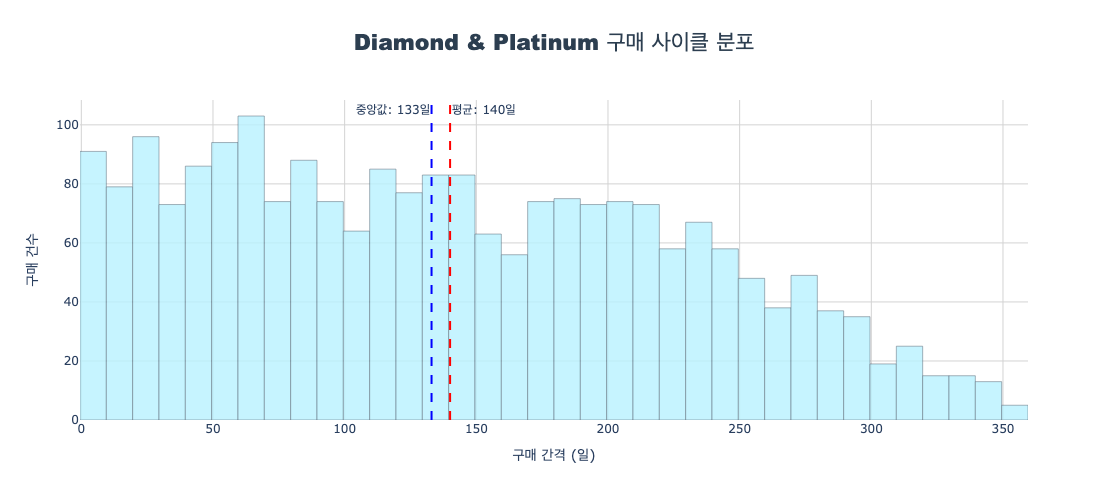

In [5]:
# 구매 사이클 시각화
fig = go.Figure(go.Histogram(
    x=df_cycle['구매_사이클'],
    marker=dict(
        color='#B9F2FF',
        line=dict(color='#2c3e50', width=0.5)
    ),
    opacity=0.8,
    nbinsx=50,
    showlegend=False
))

fig.add_vline(
    x=df_cycle['구매_사이클'].mean(),
    line_dash='dash',
    line_color='red',
    annotation_text=f"평균: {df_cycle['구매_사이클'].mean():.0f}일",
    annotation_position='top right'
)

fig.add_vline(
    x=df_cycle['구매_사이클'].median(),
    line_dash='dash',
    line_color='blue',
    annotation_text=f"중앙값: {df_cycle['구매_사이클'].median():.0f}일",
    annotation_position='top left'
)

fig.update_layout(
    title=dict(
        text='Diamond & Platinum 구매 사이클 분포',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=900,
    plot_bgcolor='white'
)

fig.update_xaxes(title_text='구매 간격 (일)', gridcolor='lightgray')
fig.update_yaxes(title_text='구매 건수', gridcolor='lightgray')

fig.show()

> 📌 **Retention 분석 단위 설정**
> 
> 평균 구매 사이클(140일, 중앙값 133일)을 고려하여 **3개월(90일) 단위**로 Retention을 분석한다. 3개월 단위로 묶으면 평균 사이클이 2번째 구간(4~6개월)에 해당하여 재구매 피크가 어느 시점에 집중되는지 더 명확하게 파악할 수 있다.

In [6]:
# Diamond/Platinum 고객 구매 이력 추출
query = """
SELECT 
    o.*, 
    r.Grade,
    DATE_FORMAT(o.OrderDate, "%Y-%m") AS OrderMonth
FROM orders_info o
JOIN rfm_result r ON o.CustomerID = r.CustomerID
WHERE r.Grade IN ('Diamond', 'Platinum')
    AND o.OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
    AND o.OrderDate <= '2024-12-29'
ORDER BY OrderDate
"""

df_dp = pd.read_sql(query, engine)

In [7]:
df_dp.head()

,OrderID,OrderDate,CustomerID,ProductID,Category,Brand,Discount,TotalAmount,PaymentMethod,Grade,OrderMonth
0,ORD0091603,2023-12-29,CUST048592,P00023,Sports & Outdoors,BrightLux,0.10,110.64,Credit Card,Platinum,2023-12
1,ORD0083273,2023-12-29,CUST005907,P00047,Clothing,KiddoFun,0.15,1432.75,UPI,Platinum,2023-12
2,ORD0098011,2023-12-29,CUST003820,P00017,Clothing,Zenith,0.10,1308.85,Amazon Pay,Diamond,2023-12
3,ORD0000587,2023-12-29,CUST044170,P00007,Sports & Outdoors,FitLife,0.20,1547.99,Debit Card,Diamond,2023-12
4,ORD0001769,2023-12-29,CUST013218,P00050,Home & Kitchen,Apex,0.30,1049.71,Debit Card,Diamond,2023-12


In [8]:
df_dp.shape

(6768, 11)

In [9]:
df_dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6768 entries, 0 to 6767
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        6768 non-null   object        
 1   OrderDate      6768 non-null   datetime64[ns]
 2   CustomerID     6768 non-null   object        
 3   ProductID      6768 non-null   object        
 4   Category       6768 non-null   object        
 5   Brand          6768 non-null   object        
 6   Discount       6768 non-null   float64       
 7   TotalAmount    6768 non-null   float64       
 8   PaymentMethod  6768 non-null   object        
 9   Grade          6768 non-null   object        
 10  OrderMonth     6768 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 581.8+ KB


In [10]:
df_dp.describe()

,OrderDate,Discount,TotalAmount
count,6768,6768.000000,6768.000000
mean,2024-09-17 13:08:56.170212864,0.072821,1016.749845
min,2023-12-29 00:00:00,0.000000,7.630000
25%,2024-08-14 00:00:00,0.000000,373.807500
50%,2024-10-28 00:00:00,0.050000,808.300000
75%,2024-11-28 00:00:00,0.100000,1579.790000
max,2024-12-29 00:00:00,0.300000,3510.230000
std,NaN,0.082924,780.766062


In [11]:
df_dp['CustomerID'].nunique()

4548

In [12]:
# 고객별 첫 구매 월 추출
first_month = df_dp.groupby('CustomerID')['OrderMonth'].min().reset_index()
first_month.columns = ['CustomerID', 'CohortMonth']

In [13]:
df_dp = df_dp.merge(first_month, on='CustomerID', how='left')

In [14]:
df_dp.head()

,OrderID,OrderDate,CustomerID,ProductID,Category,Brand,Discount,TotalAmount,PaymentMethod,Grade,OrderMonth,CohortMonth
0,ORD0091603,2023-12-29,CUST048592,P00023,Sports & Outdoors,BrightLux,0.10,110.64,Credit Card,Platinum,2023-12,2023-12
1,ORD0083273,2023-12-29,CUST005907,P00047,Clothing,KiddoFun,0.15,1432.75,UPI,Platinum,2023-12,2023-12
2,ORD0098011,2023-12-29,CUST003820,P00017,Clothing,Zenith,0.10,1308.85,Amazon Pay,Diamond,2023-12,2023-12
3,ORD0000587,2023-12-29,CUST044170,P00007,Sports & Outdoors,FitLife,0.20,1547.99,Debit Card,Diamond,2023-12,2023-12
4,ORD0001769,2023-12-29,CUST013218,P00050,Home & Kitchen,Apex,0.30,1049.71,Debit Card,Diamond,2023-12,2023-12


In [15]:
# 연산을 위해 OrderMonth 컬럼과 CohortMonth 컬럼의 타입 변경
df_dp['OrderMonth'] = pd.to_datetime(df_dp['OrderMonth']).dt.to_period('M')
df_dp['CohortMonth'] = pd.to_datetime(df_dp['CohortMonth']).dt.to_period('M')

In [16]:
# 경과 월 계산
df_dp['MonthIndex'] = (
    df_dp['OrderMonth'] - df_dp['CohortMonth']
).apply(lambda x: x.n)

In [17]:
# 0개월은 기준값, 1개월 이후부터 3개월 단위로 묶기
# 결과
# 0개월 → 0 (기준)
# 1~3개월 → 1구간
# 4~6개월 → 2구간
# 7~9개월 → 3구간
# 10~12개월 → 4구간

df_dp['QuarterIndex'] = df_dp['MonthIndex'].apply(
    lambda x: 0 if x == 0 else ((x - 1) // 3) + 1
)

In [18]:
# (첫 구매월, 3개월 경과 구간)로 묶어서 고객 수 집계
cohort_data = df_dp.groupby(['CohortMonth', 'QuarterIndex'])['CustomerID'].nunique().reset_index()

In [19]:
cohort_data.head()

,CohortMonth,QuarterIndex,CustomerID
0,2023-12,0,26
1,2023-12,1,3
2,2023-12,2,3
3,2023-12,3,9
4,2023-12,4,18


In [20]:
# 피벗 테이블 생성
cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='QuarterIndex',
    values='CustomerID'
)

In [21]:
cohort_pivot

QuarterIndex,0,1,2,3,4
CohortMonth,,,,,
2023-12,26.0,3.0,3.0,9.0,18.0
2024-01,235.0,26.0,24.0,135.0,105.0
2024-02,174.0,11.0,25.0,128.0,40.0
2024-03,217.0,20.0,87.0,150.0,NaN
2024-04,191.0,16.0,97.0,100.0,NaN
2024-05,239.0,35.0,162.0,58.0,NaN
2024-06,173.0,68.0,123.0,NaN,NaN
2024-07,171.0,90.0,91.0,NaN,NaN
2024-08,250.0,107.0,44.0,NaN,NaN


In [22]:
# 각 코호트의 첫 구매 월 고객 수 추출 (기준값)
cohort_size = cohort_pivot.iloc[:, 0]

# 전체 코호트 테이블을 첫 구매 월 고객 수로 나눠 재방문율(%) 산출
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

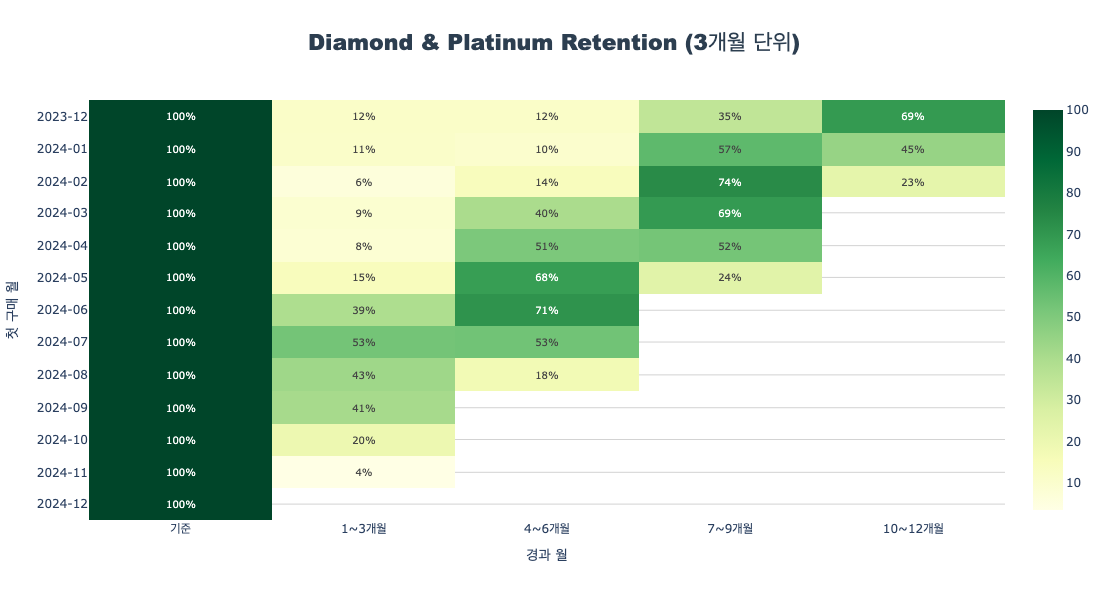

In [23]:
x_labels = {0: '기준', 1: '1~3개월', 2: '4~6개월', 3: '7~9개월', 4: '10~12개월'}
retention_sorted = retention.sort_index(ascending=True)

fig = go.Figure(go.Heatmap(
    z=retention_sorted.values,
    x=[x_labels[i] for i in retention.columns],
    y=[str(i) for i in retention_sorted.index],
    colorscale='YlGn',
    text=retention_sorted.map(lambda x: f'{x:.0f}%' if pd.notna(x) else ''),
    texttemplate='%{text}',
    textfont=dict(size=10),
    showscale=True
))

fig.update_layout(
    title=dict(
        text='Diamond & Platinum Retention (3개월 단위)',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=600,
    width=1000,
    xaxis_title='경과 월',
    yaxis_title='첫 구매 월',
    plot_bgcolor='white',
    yaxis=dict(autorange='reversed')
)

fig.update_yaxes(
    tickvals=list(retention.index.astype(str)),
    ticktext=list(retention.index.astype(str)),
    gridcolor='lightgray'
)

fig.show()

#### 코호트-달력 매핑 참고표

| 코호트 | 1~3개월 | 4~6개월 | 7~9개월 | 10~12개월 |
|--------|---------|---------|---------|----------|
| 2023-12 | 1월, 2월, 3월 | 4월, 5월, 6월 | 7월, 8월, 9월 | 10월, 11월, 12월 |
| 2024-01 | 2월, 3월, 4월 | 5월, 6월, 7월 | 8월, 9월, 10월 | 11월, 12월, 1월 |
| 2024-02 | 3월, 4월, 5월 | 6월, 7월, 8월 | 9월, 10월, 11월 | 12월 |
| 2024-03 | 4월, 5월, 6월 | 7월, 8월, 9월 | 10월, 11월, 12월 | - |
| 2024-04 | 5월, 6월, 7월 | 8월, 9월, 10월 | 11월, 12월 | - |
| 2024-05 | 6월, 7월, 8월 | 9월, 10월, 11월 | 12월 | - |
| 2024-06 | 7월, 8월, 9월 | 10월, 11월, 12월 | - | - |
| 2024-07 | 8월, 9월, 10월 | 11월, 12월 | - | - |
| 2024-08 | 9월, 10월, 11월 | 12월 | - | - |
| 2024-09 | 10월, 11월, 12월 | - | - | - |
| 2024-10 | 11월, 12월 | - | - | - |
| 2024-11 | 12월 | - | - | - |
| 2024-12 | - | - | - | - |

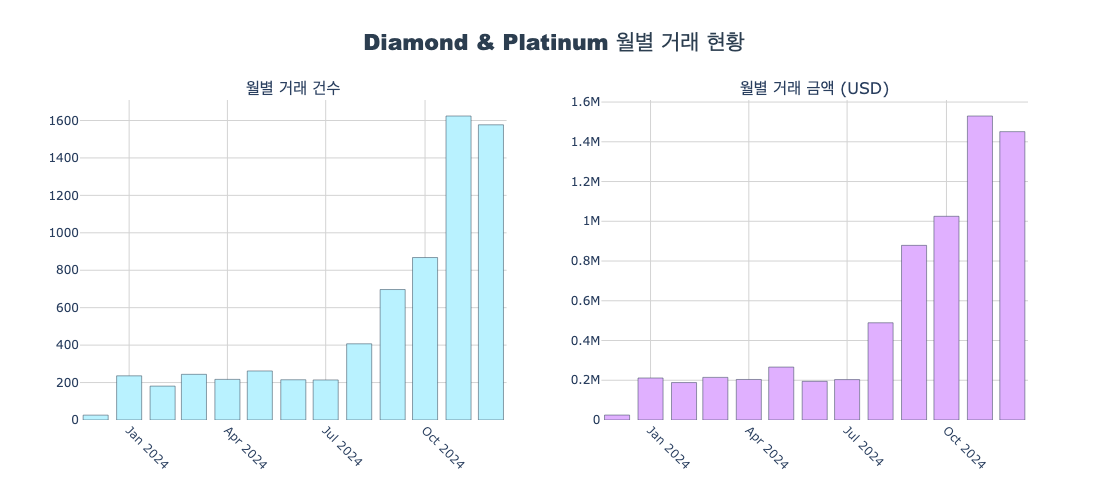

In [24]:
monthly_stats = df_dp.groupby('OrderMonth').agg(
    거래건수=('OrderID', 'count'),
    거래금액=('TotalAmount', 'sum')
).reset_index()

# 월별 거래 건수 및 월별 거래액 시각화
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['월별 거래 건수', '월별 거래 금액 (USD)']
)

fig.add_trace(
    go.Bar(
        x=monthly_stats['OrderMonth'].astype(str),
        y=monthly_stats['거래건수'],
        marker=dict(
            color='#B9F2FF',
            line=dict(color='#2c3e50', width=0.5)
        ),
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=monthly_stats['OrderMonth'].astype(str),
        y=monthly_stats['거래금액'],
        marker=dict(
            color='#E0B0FF',
            line=dict(color='#2c3e50', width=0.5)
        ),
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='Diamond & Platinum 월별 거래 현황',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=1100,
    plot_bgcolor='white'
)

fig.update_xaxes(gridcolor='lightgray', tickangle=45)
fig.update_yaxes(gridcolor='lightgray')

fig.show()

### 월별 거래 현황

월별 거래 건수와 거래 금액을 확인한 결과, 1 ~ 8월은 월 평균 USD 30만 수준으로 완만하게 유지되다가 9월부터 급격히 상승하여 11월에 거래 건수와 금액 모두 피크를 기록했다.

---

### Retention 분석 결과

> **가설 1**: 첫 구매 후 일정 시점이 지나면 재방문율이 급격히 떨어질 것이다.

분석 결과, 대부분의 코호트에서 **7 ~ 9개월 구간에서 재방문율이 높아지는 경향**이 확인되었다. 이는 평균 구매 사이클(140일 ≈ 4 ~ 5개월)과 일치하는 결과로, 첫 구매 후 단기(1 ~ 3개월) 재구매는 활발하지 않으나 평균 사이클 전후로 재구매가 집중됨을 알 수 있다.

특히 **2024-02, 2024-03, 2024-04 코호트**의 경우 7 ~ 9개월 구간에서 재방문율이 35 ~ 74%로 높게 나타났으며, 달력상 이 시점은 **9 ~ 12월**에 해당한다.

**→ 가설 검증 결과**:
- 첫 구매 후 단기 재방문율은 낮게 유지되다가 평균 구매 사이클(140일) 전후로 재구매가 집중되는 경향이 확인되어 **가설이 부분적으로 검증**되었다.

---

### 다음 분석 방향

> **가설 1-1**: 9 ~ 12월의 높은 재방문율은 블랙프라이데이 / 사이버먼데이 등 주요 할인 이벤트 시즌의 영향일 것이다.

코호트 분석에서 재방문율이 높은 시점이 달력상 9 ~ 12월과 맞물렸다. 실제 구매 월 기준 재방문율을 확인하여 특정 할인 시즌이 재구매 트리거로 작용하는지 검증한다.

| 이벤트 | 시기 |
|--------|------|
| Prime Big Deal Days | 10월 초 |
| 블랙프라이데이 / 사이버먼데이 | 11월 말 ~ 12월 초 |

In [25]:
# 실제 구매 월별 재방문율 분석을 위한 월 단위 Retention 별도 계산
cohort_data_monthly = df_dp.groupby(['CohortMonth', 'MonthIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot_monthly = cohort_data_monthly.pivot_table(
    index='CohortMonth',
    columns='MonthIndex',
    values='CustomerID'
)
cohort_size_monthly = cohort_pivot_monthly.iloc[:, 0]
retention_monthly = cohort_pivot_monthly.divide(cohort_size_monthly, axis=0).round(3) * 100

In [26]:
# 코호트 월 + 경과 월 → 실제 구매 월 계산
actual_month_data = []
for cohort in retention_monthly.index:
    for month_idx in retention_monthly.columns:
        value = retention_monthly.loc[cohort, month_idx]
        if pd.notna(value) and month_idx > 0:
            actual_month = cohort + month_idx
            actual_month_data.append({
                '실제_구매월': str(actual_month),
                '재방문율': value
            })

df_actual = pd.DataFrame(actual_month_data)
monthly_avg = df_actual.groupby('실제_구매월')['재방문율'].mean().round(2).reset_index()
monthly_avg.columns = ['월', '평균_재방문율(%)']
monthly_avg = monthly_avg.sort_values('월')

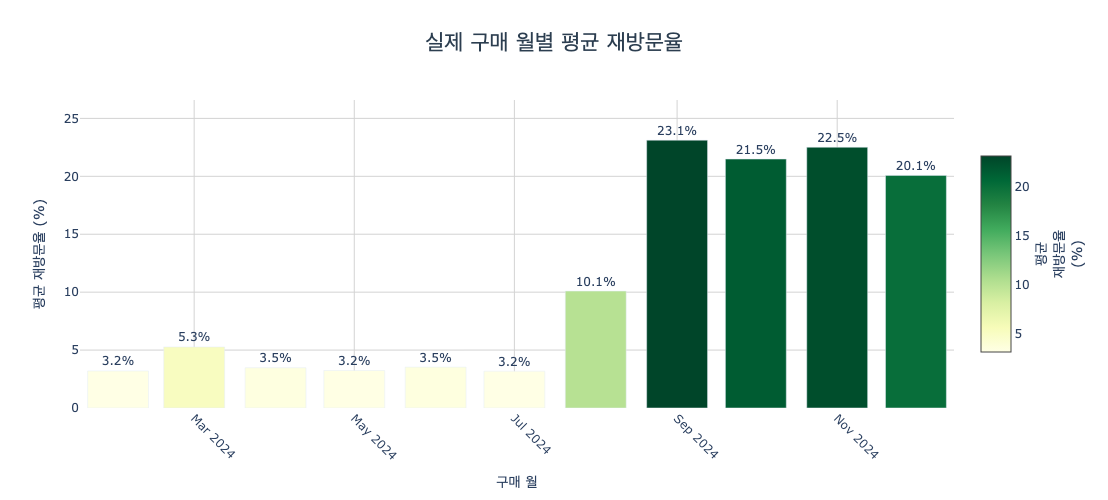

In [27]:
fig = go.Figure(go.Bar(
    x=monthly_avg['월'],
    y=monthly_avg['평균_재방문율(%)'],
    marker=dict(
        color=monthly_avg['평균_재방문율(%)'],
        colorscale='YlGn',
        showscale=True,
        colorbar=dict(
            title=dict(text='평균<br>재방문율<br>(%)', side='right'),
            len=0.7,
            y=0.5,
            yanchor='middle'
        )
    ),
    text=monthly_avg['평균_재방문율(%)'].apply(lambda x: f'{x:.1f}%'),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='실제 구매 월별 평균 재방문율',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=1000,
    plot_bgcolor='white'
)

fig.update_xaxes(title_text='구매 월', gridcolor='lightgray', tickangle=45)
fig.update_yaxes(
    title_text='평균 재방문율 (%)',
    gridcolor='lightgray',
    range=[0, monthly_avg['평균_재방문율(%)'].max() * 1.15]
)

fig.show()

### 할인 이벤트 시즌 재구매 패턴 분석

**가설 1-1**: 9 ~ 12월의 높은 재방문율은 블랙프라이데이 / 사이버먼데이 등 주요 할인 이벤트 시즌의 영향일 것이다.

실제 구매 월 기준 평균 재방문율을 확인한 결과, **9월(23.1%), 10월(21.5%), 11월(22.5%), 12월(20.1%)** 에서 높은 재방문율이 나타났다. 이벤트 시즌과 시점이 일치하는 것처럼 보이나, 특정 날짜 spike 여부를 일별로 검증이 필요하다.

> **가설 1-1 보조 검증**: 블랙프라이데이(11/29) 전후로 일별 거래 건수와 금액이 급증하는지 확인한다.

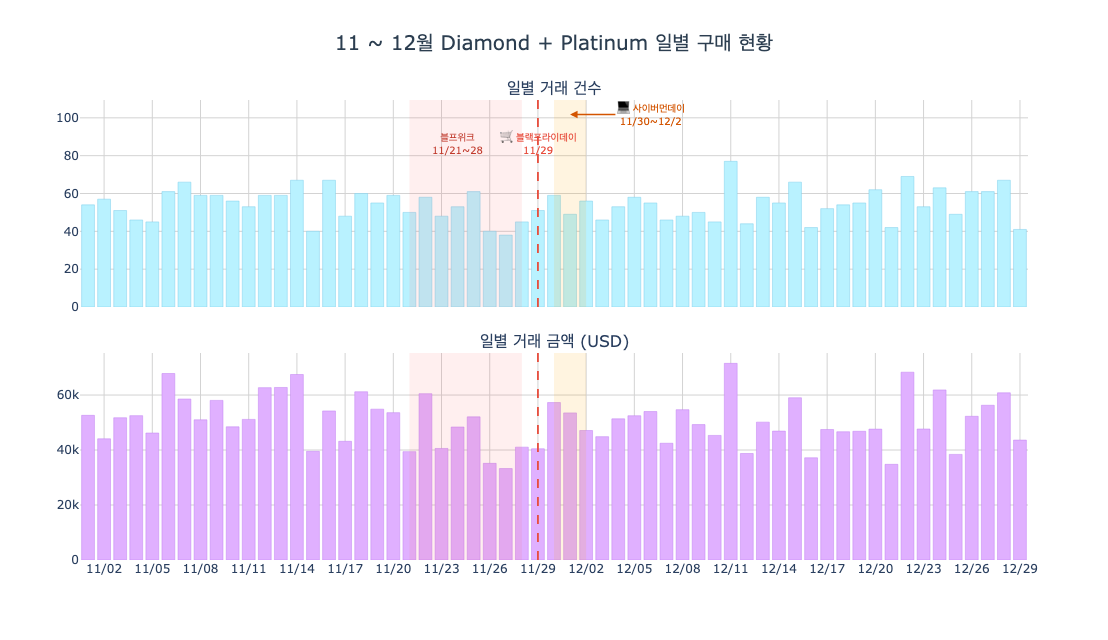

In [28]:
# 11 ~ 12월 일별 구매 건수 / 금액 (블랙프라이데이 · 사이버먼데이 보조 검증)
nov_dec_daily = pd.read_sql("""
    SELECT o.OrderDate,
           COUNT(o.OrderID)   AS 거래건수,
           SUM(o.TotalAmount) AS 거래금액
    FROM orders_info o
    JOIN rfm_result r ON o.CustomerID = r.CustomerID
    WHERE r.Grade IN ('Diamond', 'Platinum')
      AND o.OrderDate >= '2024-11-01'
      AND o.OrderDate <= '2024-12-31'
    GROUP BY o.OrderDate
    ORDER BY o.OrderDate
""", engine, parse_dates=['OrderDate'])

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=['일별 거래 건수', '일별 거래 금액 (USD)'],
    vertical_spacing=0.1
)

fig.add_trace(go.Bar(
    x=nov_dec_daily['OrderDate'],
    y=nov_dec_daily['거래건수'],
    marker_color='#B9F2FF',
    marker_line_color='#7ecfea',
    marker_line_width=0.5,
    name='거래건수'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=nov_dec_daily['OrderDate'],
    y=nov_dec_daily['거래금액'],
    marker_color='#E0B0FF',
    marker_line_color='#c080f0',
    marker_line_width=0.5,
    name='거래금액'
), row=2, col=1)

# 이벤트 기간 shaded region
events_range = [
    ('2024-11-21', '2024-11-28', 'rgba(255, 100, 100, 0.10)', '블프위크<br>11/21~11/28'),
    ('2024-11-30', '2024-12-02', 'rgba(255, 165, 0,  0.12)', '사이버먼데이<br>11/30~12/2'),
]
for x0, x1, color, label in events_range:
    for row in [1, 2]:
        fig.add_vrect(x0=x0, x1=x1, fillcolor=color, line_width=0, row=row, col=1)

# 블랙프라이데이(11/29) 수직선
for row in [1, 2]:
    fig.add_vline(x='2024-11-29', line_width=1.8,
                  line_dash='dash', line_color='#e74c3c', row=row, col=1)

# annotation (row1 기준)
y_top = nov_dec_daily['거래건수'].max() * 1.12
fig.add_annotation(x='2024-11-24', y=y_top,
    text='블프위크<br>11/21~28', showarrow=False,
    font=dict(size=10, color='#c0392b'), xref='x', yref='y')
fig.add_annotation(x='2024-11-29', y=y_top,
    text='🛒 블랙프라이데이<br>11/29', showarrow=False,
    font=dict(size=10, color='#e74c3c'), xref='x', yref='y')
fig.add_annotation(x='2024-12-01', y=y_top * 1.18,
    ax='2024-12-06', ay=y_top * 1.18,
    text='💻 사이버먼데이<br>11/30~12/2', showarrow=True,
    arrowhead=2, arrowsize=1, arrowwidth=1.5, arrowcolor='#d35400',
    font=dict(size=10, color='#d35400'),
    xref='x', yref='y', axref='x', ayref='y')

fig.update_layout(
    title=dict(
        text='11 ~ 12월 Diamond + Platinum 일별 구매 현황',
        font=dict(size=20, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    height=640,
    width=1100,
    plot_bgcolor='white',
    showlegend=False
)
fig.update_xaxes(gridcolor='lightgray', tickformat='%m/%d', dtick=86400000*3)
fig.update_yaxes(gridcolor='lightgray')

fig.show()

### 일별 거래 현황 분석 결과

일별 거래 건수와 금액을 확인한 결과, **블랙프라이데이(11/29)와 사이버먼데이(12/2) 전후로 특정 spike가 나타나지 않았다.**  
11 ~ 12월 전반에 걸쳐 거래 건수가 균등하게 분포되어 있어, 특정 이벤트 날짜의 집중 효과를 확인할 수 없었다.

이는 본 데이터셋이 **합성 데이터로 실제 이벤트 효과가 반영되지 않은 데이터 특성**에서 기인한다.

**→ 가설 1-1 보류**: 월별로는 9 ~ 12월에 재방문율이 높지만, 이것이 특정 이벤트 시즌의 영향인지는 합성 데이터 특성상 검증이 불가능하다.

---

### 형제 가설로 전환

> **가설 1-2**: 재방문율이 높은 시점(9 ~ 12월)에 재구매한 고객들은 특정 카테고리에 집중될 것이다.

9 ~ 12월 고재방문 시즌에 실제로 재구매가 발생한 거래의 카테고리 분포를 1 ~ 8월 저재방문 시즌과 비교하여, 특정 카테고리가 재구매를 주도하는지 확인한다.

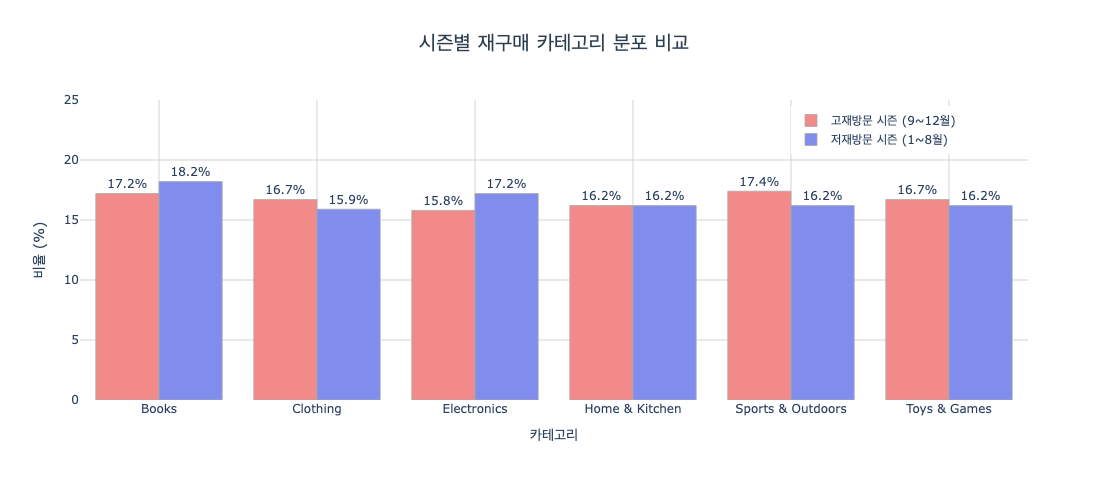

In [34]:
# 가설 1-2: 고재방문 시즌 vs 저재방문 시즌 카테고리 분포 비교
query = """
    WITH first_purchase AS (
        SELECT CustomerID, MIN(OrderDate) AS first_date
        FROM orders_info
        GROUP BY CustomerID
    )
    SELECT o.CustomerID, o.OrderDate, o.Category,
           MONTH(o.OrderDate) AS 구매월
    FROM orders_info o
    JOIN rfm_result r ON o.CustomerID = r.CustomerID
    JOIN first_purchase f ON o.CustomerID = f.CustomerID
    WHERE r.Grade IN ('Diamond', 'Platinum')
      AND o.OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
      AND o.OrderDate <= '2024-12-29'
      AND o.OrderDate > f.first_date
"""
df_repurchase = pd.read_sql(query, engine, parse_dates=['OrderDate'])
df_repurchase['시즌'] = df_repurchase['구매월'].apply(
    lambda x: '고재방문 시즌 (9~12월)' if x >= 9 else '저재방문 시즌 (1~8월)'
)

# 시즌별 카테고리 비율
season_cat = df_repurchase.groupby(['시즌', 'Category']).size().reset_index(name='건수')
season_total = df_repurchase.groupby('시즌').size().reset_index(name='합계')
season_cat = season_cat.merge(season_total, on='시즌')
season_cat['비율(%)'] = (season_cat['건수'] / season_cat['합계'] * 100).round(1)

categories = sorted(season_cat['Category'].unique())
colors = {'고재방문 시즌 (9~12월)': '#f28a8a', '저재방문 시즌 (1~8월)': '#808ded'}

fig = go.Figure()
for season, color in colors.items():
    subset = season_cat[season_cat['시즌'] == season].set_index('Category').reindex(categories)
    fig.add_trace(go.Bar(
        name=season,
        x=categories,
        y=subset['비율(%)'],
        marker_color=color,
        marker_line_color='#aaa',
        marker_line_width=0.8,
        text=subset['비율(%)'].apply(lambda x: f'{x:.1f}%'),
        textposition='outside'
    ))

fig.update_layout(
    title=dict(
        text='시즌별 재구매 카테고리 분포 비교',
        font=dict(size=20, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    barmode='group',
    xaxis=dict(title='카테고리', gridcolor='lightgray'),
    yaxis=dict(title='비율 (%)', gridcolor='lightgray', range=[0, 25]),
    plot_bgcolor='white',
    height=480,
    width=920,
    legend=dict(x=0.75, y=0.98)
)
fig.show()

### 카테고리 분포 비교 분석 결과

**→ 가설 1-2 기각**: 고재방문 시즌(9 ~ 12월)과 저재방문 시즌(1 ~ 8월) 간 카테고리 분포 차이가 유의미하지 않다 (최대 1.4%p).

모든 카테고리가 두 시즌에 걸쳐 15 ~ 18% 수준으로 고르게 분포되어 있어, 특정 카테고리가 재구매를 주도하지 않는다.  
가설 1-1과 마찬가지로 합성 데이터 특성상 실제 패턴이 반영되지 않은 영향도 있으나, **Diamond + Platinum 등급 고객의 재구매는 특정 시즌이나 카테고리에 의존하지 않고 고객 자체의 높은 충성도에서 비롯됨**을 시사한다.

---

## **VIP 고객 (Diamond + Platinum) 솔루션**

### 분석 결과 요약

- 평균 구매 사이클(140일) 전후인 **4 ~ 5개월 구간**에서 재구매 집중
- 9 ~ 12월에 전반적으로 높은 재방문율 (20 ~ 23%) 유지
- 이벤트 시즌 / 카테고리와 무관하게 **고객 자체의 충성도**가 재구매를 주도

---

> ✅ **액션 아이템**
>
> **💎 Diamond 대상**
> - **1**. Diamond 전용 페이백 서비스 및 전용 고객센터 운영
> - **2**. 할인 이벤트 **24시간 전 얼리 액세스** 제공으로 VIP 경험 강화
> > - 예) 블랙프라이데이 딜을 일반 고객보다 하루 먼저 접근 가능
> - **3**. **"Diamond 등급 유지까지 USD XXX 남았습니다"** 등급 유지 알림 발송
>
> **🔮 Platinum 대상**
> - **1**. **"Platinum → Diamond까지 USD XXX 남았습니다"** 등급 전환 알림
> - **2**. 등급 상승 시 즉시 보상 제공으로 재구매 동기 부여
>
> **💎🔮 Diamond + Platinum 공통**
> - **1**. 평균 구매 사이클(140일) 기반 **4 ~ 5개월 시점** 개인화 상품 추천 + 맞춤형 쿠폰 발송
> - **2**. Prime Big Deal Days(10월), 블랙프라이데이(11월) **3 ~ 4주 전** 얼리버드 쿠폰 발송
> - **3**. 반복 구매 상품 대상 Subscribe & Save 구독 전환 유도

---

> 🧪 **A/B 테스트 제안**
>
> **💎 Diamond 대상**
> - 등급 유지 알림 vs 일반 프로모션 알림
> > - 가설: 등급 유지 알림이 일반 프로모션 알림보다 재구매 동기를 더 효과적으로 자극할 것이다
> > - A그룹: 일반 할인 프로모션 알림 발송
> > - B그룹: "Diamond 등급 유지까지 USD XXX 남았습니다" 등급 유지 알림 발송
> - **주요 지표(Primary KPI)**: 알림 발송 후 30일 내 재구매율, 전환율
> - **보조 지표(Secondary KPI)**: AOV(평균 주문 금액), ARPU(고객당 평균 매출)
>
> **🔮 Platinum 대상**
> - 등급 전환 알림 vs 일반 할인 쿠폰
> > - 가설: 등급 전환 알림이 일반 할인 쿠폰보다 추가 구매 동기를 더 효과적으로 자극할 것이다
> > - A그룹: 일반 할인 쿠폰 발송
> > - B그룹: "Diamond까지 USD XXX 남았습니다" 등급 전환 알림 발송
> - **주요 지표(Primary KPI)**: 알림 발송 후 30일 내 재구매율, 전환율
> - **보조 지표(Secondary KPI)**: AOV(평균 주문 금액), ARPU(고객당 평균 매출)
>
> **💎🔮 Diamond + Platinum 공통**
> - 구매 사이클 기반 타겟팅 vs 일반 타겟팅
> > - 가설: 구매 사이클 도래 시점(140일 기준)에 타겟팅할 경우 전환율과 재구매율이 더 높을 것이다
> > - A그룹: 전체 고객 대상 일반 프로모션 발송
> > - B그룹: 구매 사이클 도래 시점 고객만 타겟팅하여 개인화 프로모션 발송
> - **주요 지표(Primary KPI)**: 전환율, 재구매율
> - **보조 지표(Secondary KPI)**: AOV, ARPU, ROI
> ---
> - **실험 단위**: 고객 단위 랜덤 할당 (User-level Randomization)
> - **실험 기간**: 최소 1 구매 사이클 이상(약 4~5개월)
> - **실험 설계 유의사항**: 동일 고객이 복수 실험에 동시에 노출되지 않도록 상호 배타적 그룹으로 분리